# Phase 4 — Feature Engineering

Builds `data/processed/features_product.parquet`:
one row per (ProductID, week_start) with 49 feature columns and the `qty` target.

**Leakage prevention:** every lag and rolling feature is shifted by at least 1 week
within each product group so that week *t* never sees its own qty value.

Figures 18–21 are saved to `outputs/figures/` at 140 dpi.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import colormaps

from src.features import build_features

FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
FEAT_PARQUET = ROOT / "data" / "processed" / "features_product.parquet"

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 140,
    "figure.facecolor": "white", "axes.facecolor": "#f8f8f8",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35, "grid.color": "#cccccc",
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "legend.frameon": False,
})

def savefig(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight", dpi=140)
    print(f"Saved -> {name}")


In [2]:
# Build / reload features
if not FEAT_PARQUET.exists():
    print("Running build_features() ...")
    feat, summary = build_features(
        weekly_product_path=ROOT / "data/processed/weekly_product.parquet",
        segments_path=ROOT / "data/processed/product_segments.parquet",
        transactions_path=ROOT / "data/processed/transactions_clean.parquet",
        out_path=FEAT_PARQUET,
    )
    print(f"Built: {feat.shape}, dropped: {summary['dropped_cols']}")
else:
    feat = pd.read_parquet(FEAT_PARQUET)
    feat["week_start"] = pd.to_datetime(feat["week_start"])
    for col in feat.select_dtypes("object").columns:
        if col != "ProductID":
            feat[col] = feat[col].astype("category")
    summary = None
    print(f"Loaded {FEAT_PARQUET.name}: {feat.shape}")


Loaded features_product.parquet: (1521270, 52)


In [3]:
# Summary
KEY_TARGET = {"ProductID", "week_start", "qty"}
feat_cols  = [c for c in feat.columns if c not in KEY_TARGET]
num_feats  = feat.select_dtypes(include="number").columns.difference(list(KEY_TARGET)).tolist()
cat_feats  = [c for c in feat_cols if c not in num_feats]

SEP = "=" * 65
print(SEP)
print("PHASE 4 FEATURE ENGINEERING SUMMARY")
print(SEP)
print(f"  Rows                : {len(feat):,}")
print(f"  Total feature cols  : {len(feat_cols)}")
print(f"    numeric           : {len(num_feats)}")
print(f"    categorical       : {len(cat_feats)}")
if summary and summary["dropped_cols"]:
    print(f"  Dropped (constant / all-null): {summary['dropped_cols']}")
else:
    print("  Dropped (constant / all-null): none")
print()
print("  Numeric feature columns:")
for i, c in enumerate(num_feats, 1):
    miss_pct = feat[c].isna().mean() * 100
    print(f"    {i:>2}. {c:<40}  {miss_pct:5.1f}% missing")
print()
print("  Categorical feature columns:")
for c in cat_feats:
    n_cats = feat[c].nunique()
    print(f"    {c:<40}  {n_cats} categories")
print(SEP)


PHASE 4 FEATURE ENGINEERING SUMMARY
  Rows                : 1,521,270
  Total feature cols  : 49
    numeric           : 40
    categorical       : 9
  Dropped (constant / all-null): none

  Numeric feature columns:
     1. cos_annual                                  0.0% missing
     2. cumulative_active_weeks                     0.0% missing
     3. expanding_mean_demand                       0.9% missing
     4. month                                       0.0% missing
     5. promo_share_12w                             0.9% missing
     6. promo_share_4w                              0.9% missing
     7. promo_sum_12w                               0.9% missing
     8. promo_sum_4w                                0.9% missing
     9. qty_lag_12w                                10.5% missing
    10. qty_lag_1w                                  0.9% missing
    11. qty_lag_2w                                  1.8% missing
    12. qty_lag_3w                                  2.7% missing
    

Saved -> 18_corr_matrix.png


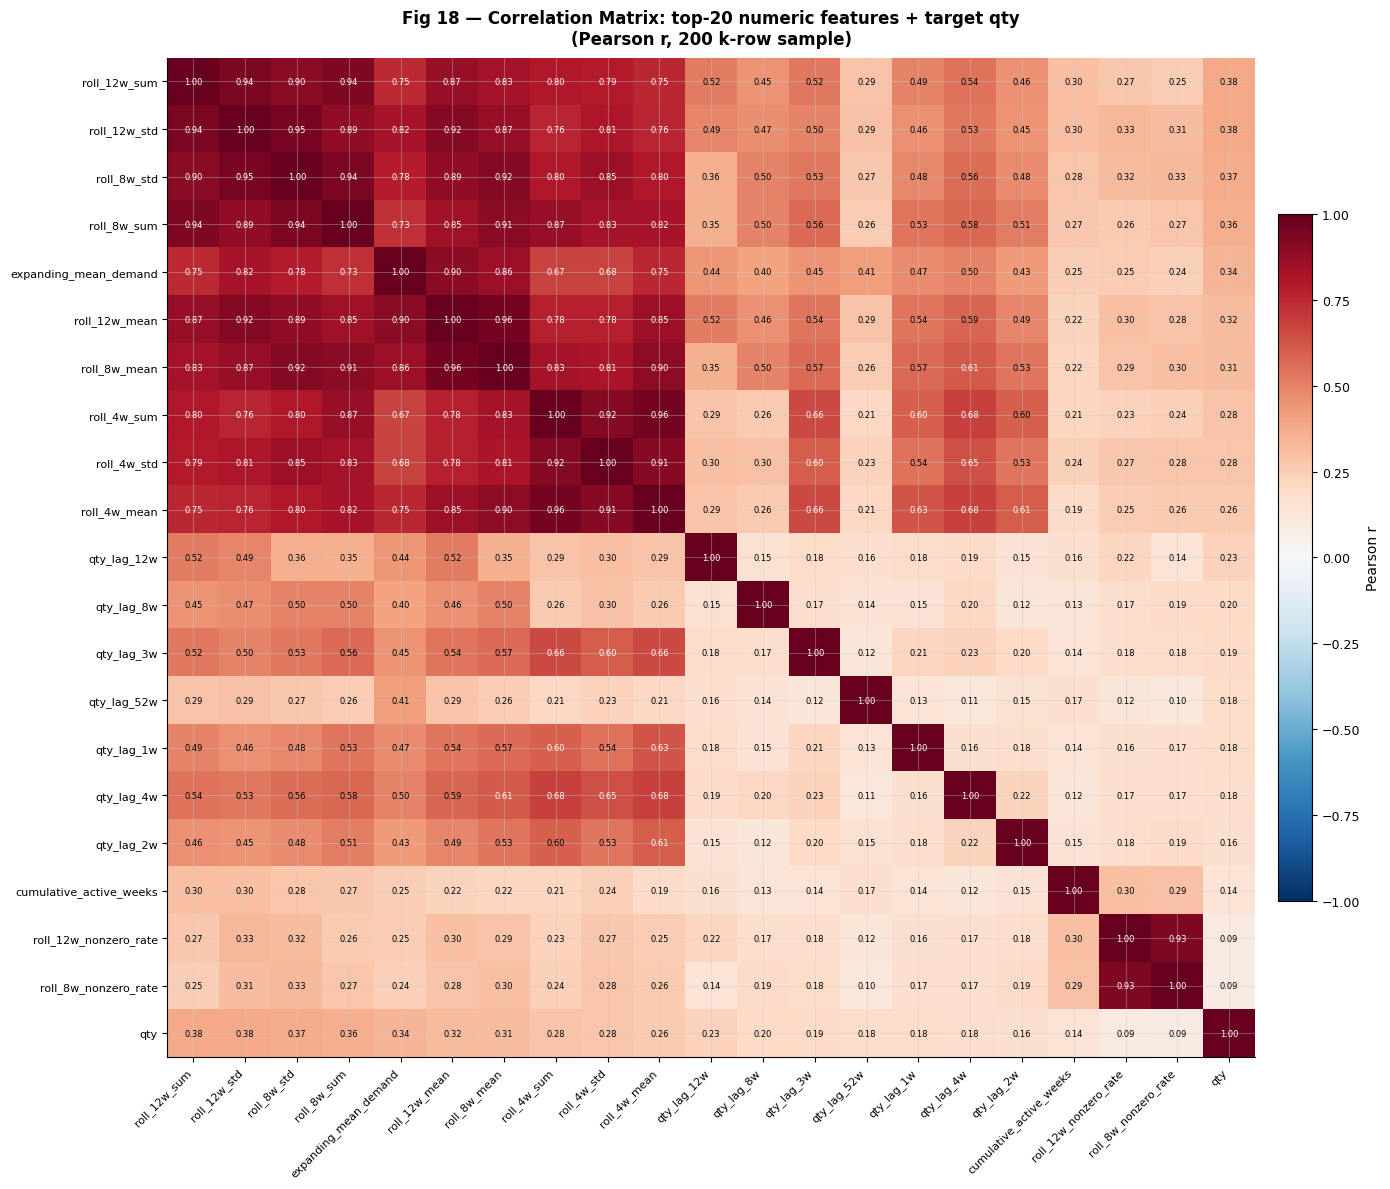

In [4]:
# ── Fig 18 — Correlation matrix heatmap (top-N numeric features by |corr| with qty) ──
# Use a random sample (200 k rows) to keep computation fast
rng = np.random.default_rng(42)
idx = rng.choice(len(feat), size=min(200_000, len(feat)), replace=False)
sample = feat.iloc[idx]

corr_with_target = (
    sample[num_feats + ["qty"]]
    .corr()["qty"]
    .drop("qty")
    .dropna()
)
TOP_N = 20
top_feats = corr_with_target.abs().nlargest(TOP_N).index.tolist()
sub_cols   = top_feats + ["qty"]
corr_matrix = sample[sub_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Pearson r")

ticks = range(len(sub_cols))
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels(sub_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(sub_cols, fontsize=8)

# Annotate cells
for i in range(len(sub_cols)):
    for j in range(len(sub_cols)):
        val = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)

ax.set_title(
    f"Fig 18 — Correlation Matrix: top-{TOP_N} numeric features + target qty\n"
    "(Pearson r, 200 k-row sample)",
    pad=10,
)
plt.tight_layout()
savefig(fig, "18_corr_matrix.png")
plt.show()


Saved -> 19_feature_target_correlations.png


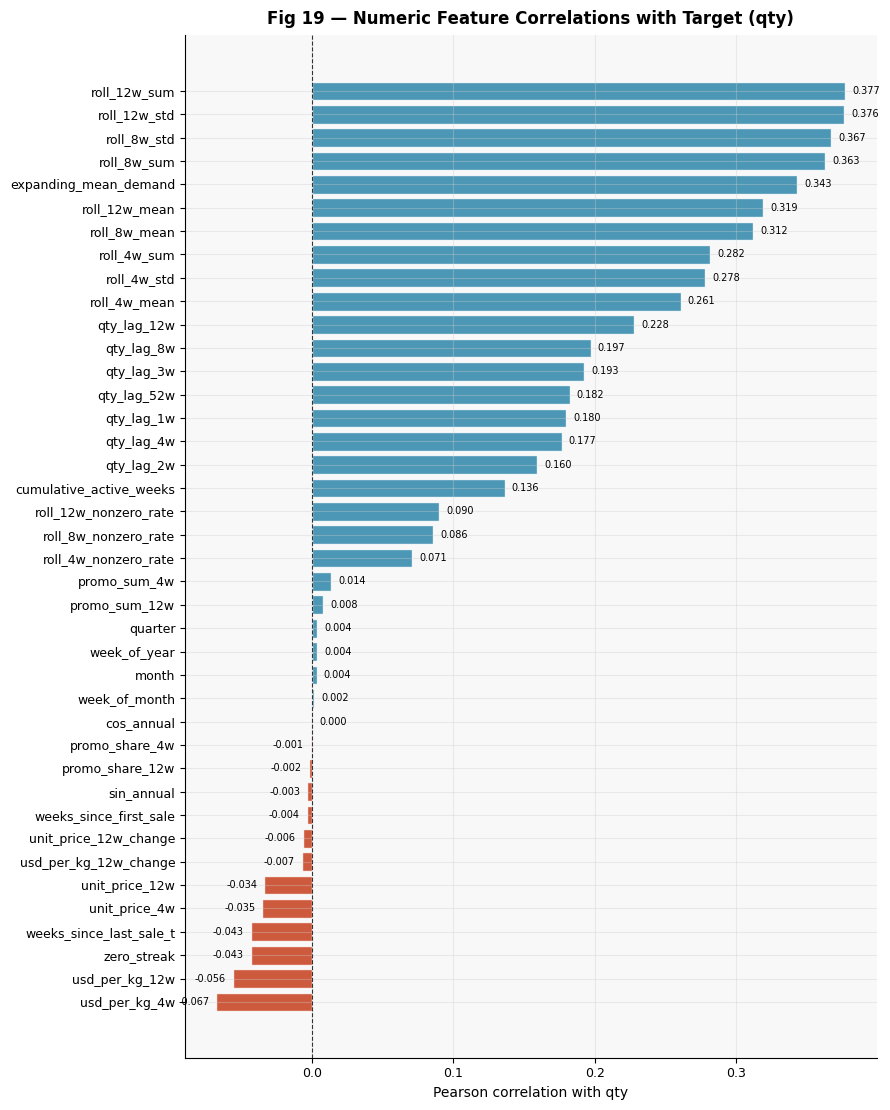

In [5]:
# ── Fig 19 — Bar chart: each numeric feature's correlation with qty ──────────
corr_all = corr_with_target.reindex(num_feats).dropna().sort_values()

colours = ["#C73E1D" if v < 0 else "#2E86AB" for v in corr_all.values]

fig, ax = plt.subplots(figsize=(9, max(6, len(corr_all) * 0.28)))
bars = ax.barh(corr_all.index, corr_all.values, color=colours, alpha=0.85, edgecolor="white")
ax.axvline(0, color="#333333", linewidth=0.8, linestyle="--")
ax.set_xlabel("Pearson correlation with qty")
ax.set_title("Fig 19 — Numeric Feature Correlations with Target (qty)", pad=8)

for bar, val in zip(bars, corr_all.values):
    xpad = 0.005 if val >= 0 else -0.005
    ha   = "left"  if val >= 0 else "right"
    ax.text(val + xpad, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha=ha, fontsize=7)

plt.tight_layout()
savefig(fig, "19_feature_target_correlations.png")
plt.show()


Saved -> 20_feature_missingness.png


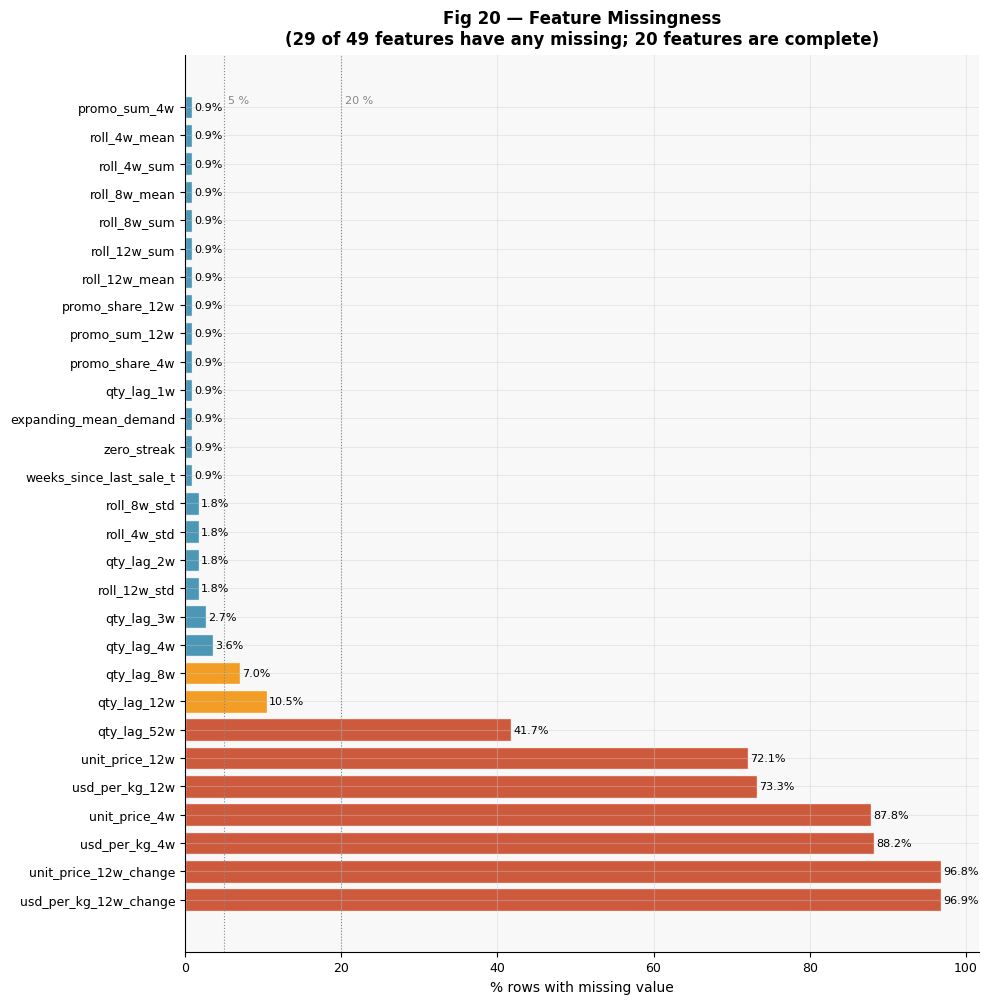

In [6]:
# ── Fig 20 — Missingness check on feature columns ────────────────────────────
miss = (feat[feat_cols].isna().mean() * 100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, max(5, len(miss_nonzero) * 0.35)))
colours_m = ["#C73E1D" if v > 20 else "#F18F01" if v > 5 else "#2E86AB"
             for v in miss_nonzero.values]
ax.barh(miss_nonzero.index, miss_nonzero.values, color=colours_m,
        alpha=0.85, edgecolor="white")
ax.set_xlabel("% rows with missing value")
ax.set_title(
    f"Fig 20 — Feature Missingness\n"
    f"({len(miss_nonzero)} of {len(feat_cols)} features have any missing; "
    f"{(miss == 0).sum()} features are complete)",
    pad=8,
)
ax.axvline(5,  color="#888", linewidth=0.8, linestyle=":")
ax.axvline(20, color="#888", linewidth=0.8, linestyle=":")
ax.text(5.5,  len(miss_nonzero) * 0.97, "5 %",  fontsize=8, color="#888")
ax.text(20.5, len(miss_nonzero) * 0.97, "20 %", fontsize=8, color="#888")

for i, (feat_name, val) in enumerate(miss_nonzero.items()):
    ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=8)

plt.tight_layout()
savefig(fig, "20_feature_missingness.png")
plt.show()


Saved -> 21_example_product_features.png


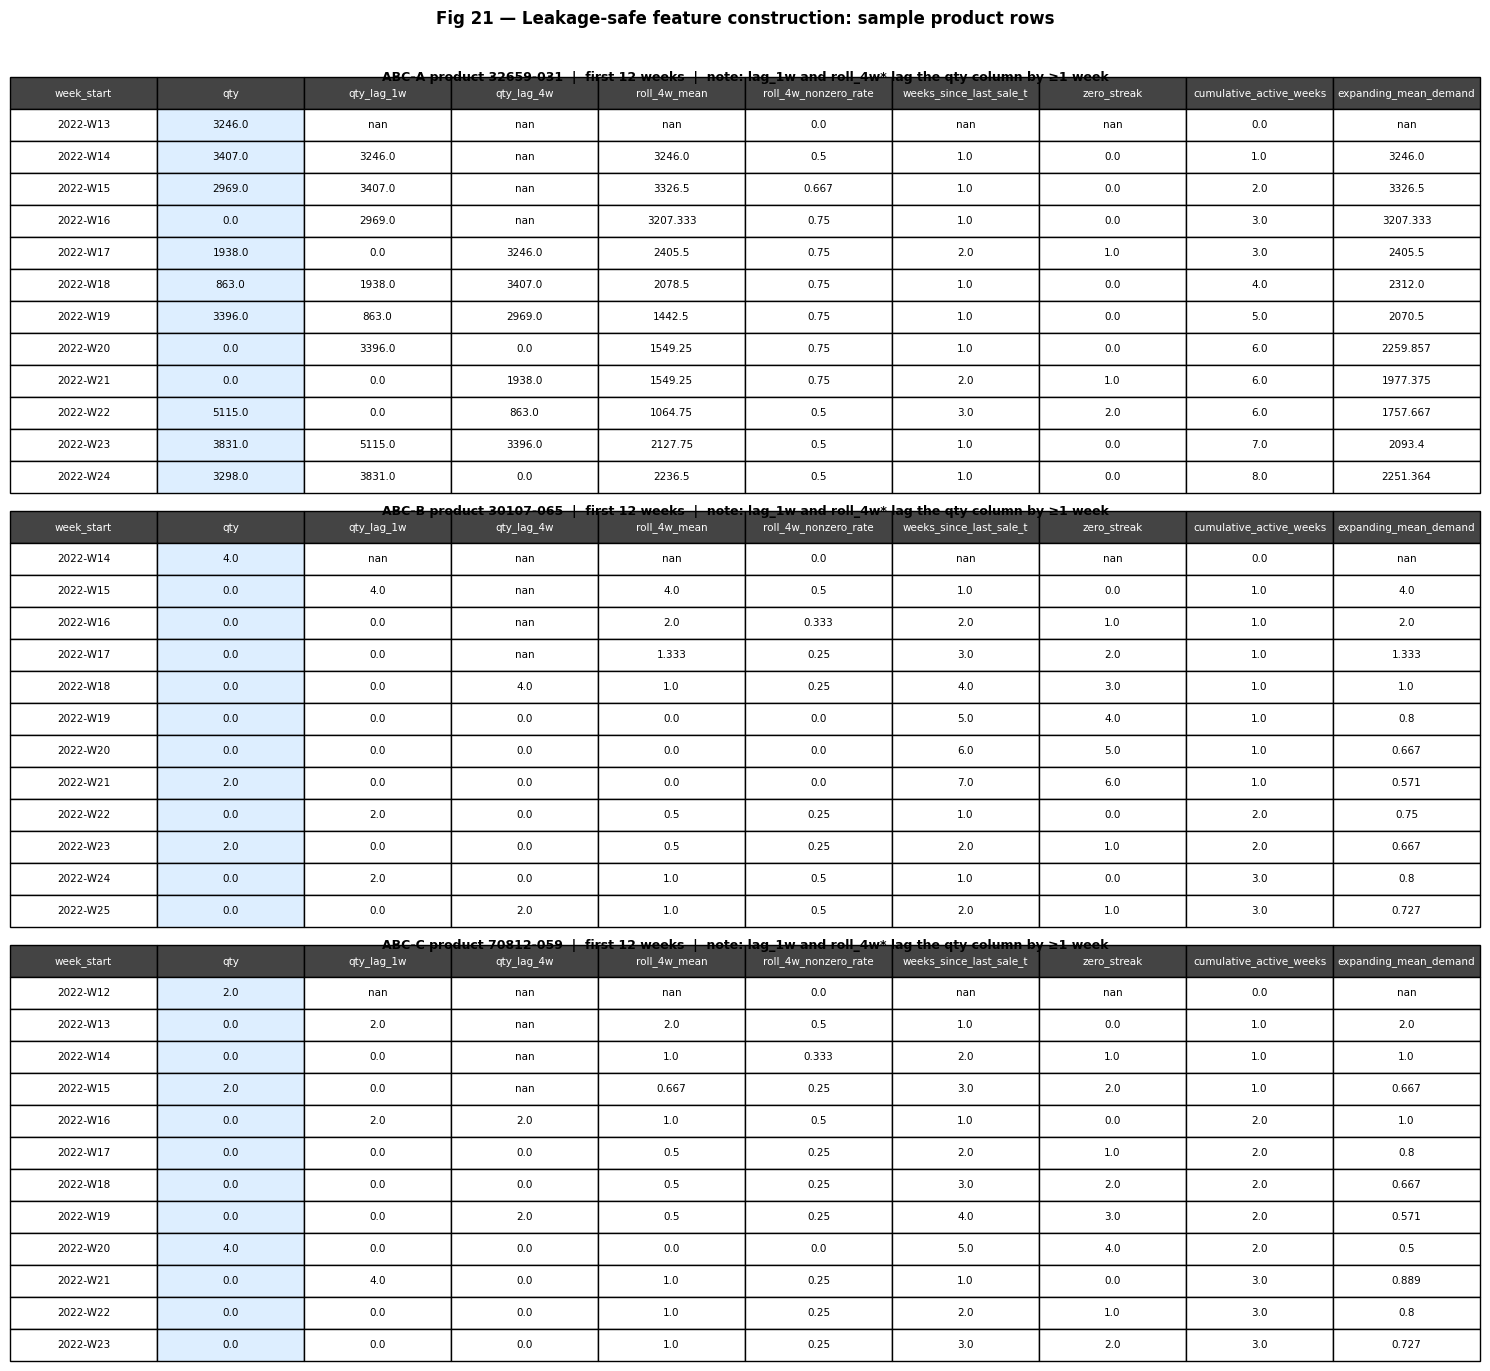

In [7]:
# ── Fig 21 — Example rows: leakage-safe feature construction is visible ───────
# Pick 3 products: one per abc_class (A, B, C) with some active weeks
examples = {}
for cls in ["A", "B", "C"]:
    pids = (
        feat[feat["abc_class"] == cls]
        .groupby("ProductID")["qty"]
        .apply(lambda x: (x > 0).sum())
        .sort_values(ascending=False)
        .head(5)
        .index
    )
    # pick the first product that has > 5 active weeks
    for pid in pids:
        sub = feat[feat["ProductID"] == pid].head(12)
        if sub["qty"].gt(0).sum() >= 2:
            examples[cls] = (pid, sub)
            break

display_cols = [
    "week_start", "qty",
    "qty_lag_1w", "qty_lag_4w",
    "roll_4w_mean", "roll_4w_nonzero_rate",
    "weeks_since_last_sale_t", "zero_streak",
    "cumulative_active_weeks", "expanding_mean_demand",
]

fig, axes = plt.subplots(len(examples), 1, figsize=(15, 4.5 * len(examples)))
if len(examples) == 1:
    axes = [axes]

for ax, (cls, (pid, sub)) in zip(axes, examples.items()):
    sub_disp = sub[display_cols].copy()
    sub_disp["week_start"] = sub_disp["week_start"].dt.strftime("%Y-W%V")

    # Render as table
    ax.axis("off")
    col_labels = display_cols
    cell_vals  = sub_disp.values.tolist()
    tbl = ax.table(
        cellText=[[str(round(v, 3)) if isinstance(v, float) else str(v) for v in row]
                  for row in cell_vals],
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.scale(1, 1.5)
    # highlight the qty column (target)
    for row_i in range(len(cell_vals)):
        tbl[(row_i + 1, 1)].set_facecolor("#DDEEFF")
    for col_i, col_name in enumerate(col_labels):
        tbl[(0, col_i)].set_facecolor("#444444")
        tbl[(0, col_i)].set_text_props(color="white", fontsize=7.5)

    ax.set_title(
        f"ABC-{cls} product {pid}  |  first 12 weeks  "
        f"|  note: lag_1w and roll_4w* lag the qty column by ≥1 week",
        fontsize=9, pad=6,
    )

fig.suptitle("Fig 21 — Leakage-safe feature construction: sample product rows",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
savefig(fig, "21_example_product_features.png")
plt.show()


In [8]:
print("\nPhase 4 figures saved:")
for f in sorted(p for p in (ROOT / "outputs" / "figures").iterdir()
                if p.suffix == ".png" and int(p.stem[:2]) >= 18):
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name}  ({size_kb} KB)")
print("\nFeature table saved to:", FEAT_PARQUET)
print(f"Shape: {feat.shape} | Memory: {feat.memory_usage(deep=True).sum() / 1e6:.1f} MB")



Phase 4 figures saved:
  18_corr_matrix.png  (340 KB)
  19_feature_target_correlations.png  (143 KB)
  20_feature_missingness.png  (135 KB)
  21_example_product_features.png  (245 KB)

Feature table saved to: /Users/nethmini/Documents/GitHub/Cinnamon-Export-Sales-Forecasting/data/processed/features_product.parquet
Shape: (1521270, 52) | Memory: 346.9 MB
